In [1]:
import pyspark
from pyspark.sql import SparkSession

spark = (SparkSession.builder 
    .appName("EDA_PaymentMethod")
    .config("spark.driver.memory", "4g")
    .config("spark.executor.memory", "4g")
    .getOrCreate()
)

print("Spark version:", spark.version)

Spark version: 3.5.0


In [2]:
from pyspark.sql import functions as F
import pandas as pd
pd.set_option('display.max_columns', None)
import plotly.express as px
import plotly.graph_objects as go
path = "/home/jovyan/work/data/bronze/"

A continuación procederemos a analizar el volumen de dinero defraudado, dado que los datos estan sesgados en el tiempo, primero analizaremos el volumen total con respecto al año 2010, y los promedios con todo el conjunto no sesgado


In [3]:
amountchip_fraud_unbiased_df = (
    spark.read.parquet(f"{path}complete_fraud_data_df.parquet")
    .withColumn("day", F.to_date(F.col("date")))
    .filter(
        (F.col("day").between("2010-01-01", "2011-01-08")) |
        (F.col("day").between("2013-07-19", "2014-04-08")) |
        (F.col("day").between("2015-03-30", "2016-12-22"))
    )
    .filter(F.col("day") != "2016-02-29")
    .filter(F.col("target").isNotNull())
    .withColumn("target", 
        F.when(F.col("target") == True, "Fraudulent")
         .when(F.col("target") == False, "Legitimate")
    )
    .select("amount", "target", "use_chip", "day", "client_id")
)

Filas_unbiased = amountchip_fraud_unbiased_df.count()
Columnas_unbiased = len(amountchip_fraud_unbiased_df.columns)

print(f"Filas: {Filas_unbiased}, Columnas: {Columnas_unbiased}")
amountchip_fraud_unbiased_df.printSchema()
amountchip_fraud_unbiased_df.limit(5).toPandas()

Filas: 3128626, Columnas: 5
root
 |-- amount: double (nullable = true)
 |-- target: string (nullable = true)
 |-- use_chip: string (nullable = true)
 |-- day: date (nullable = true)
 |-- client_id: string (nullable = true)



,amount,target,use_chip,day,client_id
0,20.24,Legitimate,Online Transaction,2013-07-19,1684
1,3.99,Legitimate,Swipe Transaction,2013-07-19,246
2,3.60,Legitimate,Swipe Transaction,2013-07-19,150
3,4.73,Legitimate,Swipe Transaction,2013-07-19,1102
4,45.71,Legitimate,Swipe Transaction,2013-07-19,843


In [4]:
chip_evolution_df = (
    amountchip_fraud_unbiased_df
    .groupBy("use_chip", "day", "target") 
    .count()
    .orderBy("use_chip", "day", "target")
)
chip_evolution_df.show(10)

+----------------+----------+----------+-----+
|        use_chip|       day|    target|count|
+----------------+----------+----------+-----+
|Chip Transaction|2015-03-30|Fraudulent|    1|
|Chip Transaction|2015-03-30|Legitimate| 1922|
|Chip Transaction|2015-03-31|Legitimate| 1887|
|Chip Transaction|2015-04-01|Legitimate| 1869|
|Chip Transaction|2015-04-02|Legitimate| 1692|
|Chip Transaction|2015-04-03|Fraudulent|    1|
|Chip Transaction|2015-04-03|Legitimate| 1685|
|Chip Transaction|2015-04-04|Legitimate| 1881|
|Chip Transaction|2015-04-05|Legitimate| 1855|
|Chip Transaction|2015-04-06|Fraudulent|    2|
+----------------+----------+----------+-----+
only showing top 10 rows



In [5]:
chip_color = {
    'Online Transaction': '#7EA1B5', 
    'Swipe Transaction': '#F2A183', 
    'Chip Transaction': '#89D3C2'
}

chip_order = ["Online Transaction", "Chip Transaction", "Swipe Transaction"]

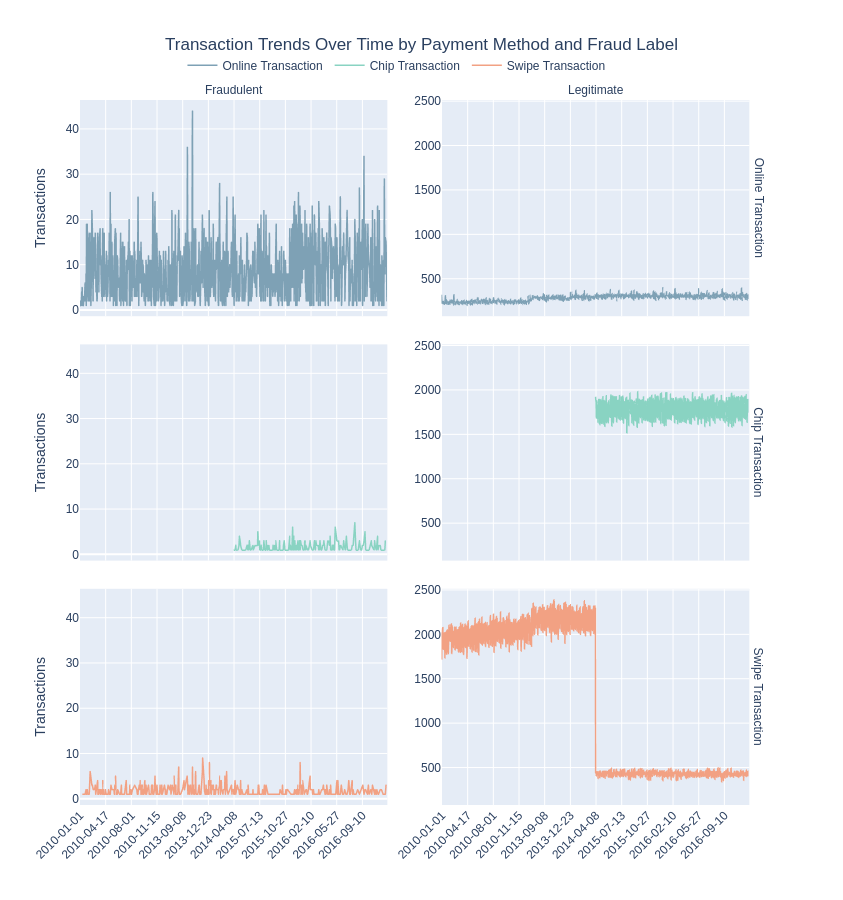

In [12]:
chip_evolution_pd = chip_evolution_df.toPandas()
ordered_days = sorted(chip_evolution_pd['day'].unique())

chip_evolution_plot = px.scatter(
    chip_evolution_pd,
    x="day",          
    y="count",
    color="use_chip",
    facet_col="target",         
    facet_row="use_chip",   
    facet_row_spacing=0.04,    
    facet_col_spacing=0.08,     
    title="Transaction Trends Over Time by Payment Method and Fraud Label",
    labels={"day": "", "count": "Transactions", "target": "Is Fraud?"},
    color_discrete_map= chip_color,
    category_orders={"use_chip": chip_order},
    custom_data=["target"]     
)

chip_evolution_plot.update_traces(
    mode="lines",               
    line=dict(width=1.5),   
    hovertemplate="<b>Date:</b> %{x|%A, %d %b %Y}<br><b>Count:</b> %{y:,}<extra></extra>"
)

chip_evolution_plot.update_yaxes(
    showspikes=True, spikemode='across', spikethickness=1, spikedash='dash', spikecolor="#040404"
)
    
chip_evolution_plot.update_yaxes(matches="y", showticklabels=True, col=1)
chip_evolution_plot.update_yaxes(matches="y2",showticklabels=True, col=2)

chip_evolution_plot.update_xaxes(
    showticklabels=True, tickformat='%b %Y', matches="x", tickangle=-45, nticks=12,
    type='category', categoryorder='array', categoryarray=ordered_days,
    showspikes=True, spikemode='across', spikethickness=1, spikedash='dash', spikecolor="#040404",
) 

chip_evolution_plot.update_xaxes(showticklabels=False, row=2)
chip_evolution_plot.update_xaxes(showticklabels=False, row=3)

chip_evolution_plot.update_layout(
    title_x=0.5,
    width=850, height=900, autosize=False,                
    hovermode="x",     
    legend=dict(title="", orientation="h", yanchor="top", y=1.07, xanchor="left", x=0.15),
)

chip_evolution_plot.for_each_annotation(lambda a: a.update(text=a.text.split('=')[-1]))

chip_evolution_plot.show()


Debido a que hay tendencias que no se entiendo más que como falta de registros por sesgos seleccionaremos filtraremos nuestros datos para analizarlos durante elperiodo de un año-, el periodo elegido es de 30 de Marzo de 2015 a 29 de Marzo de 2016. Ya que antes de esa fecha no hay registro de transacciones con chip, lo cual puede entorpecer el modelado. Además de que a partir de esa fecha se observa un amplio descenso en el número de operaciones swipe, sin embargo esto no va de la mano con un descenso en el número de registros de fraude, por lo que a priori se fortalece la idea de que hay un error en el registro.  
Buscar cuando salio nueva tarjeta para uso de pin

In [6]:
amountchip_fraud_unbiased2_df = (
    amountchip_fraud_unbiased_df.filter(F.col("day").between("2015-03-30", "2016-03-29"))
)

amountchip_fraud_unbiased2_df.limit(5).toPandas()

,amount,target,use_chip,day,client_id
0,156.60,Legitimate,Chip Transaction,2015-03-30,1079
1,2.61,Legitimate,Chip Transaction,2015-03-30,461
2,7.02,Legitimate,Chip Transaction,2015-03-30,1295
3,-79.00,Legitimate,Chip Transaction,2015-03-30,1098
4,8.86,Legitimate,Swipe Transaction,2015-03-30,1809


In [7]:
total_amountchip_df = (
    amountchip_fraud_unbiased2_df
    .filter(F.year(F.col("day")) == 2016)
    .groupBy("target", "use_chip")
    .agg(
        F.count("amount").alias("total_transactions"),
        F.round(F.sum("amount"), 2).alias("total_amount")
    )
    .orderBy(F.desc("total_amount"))
)

total_amountchip_df.show()

+----------+------------------+------------------+------------+
|    target|          use_chip|total_transactions|total_amount|
+----------+------------------+------------------+------------+
|Legitimate|  Chip Transaction|            159161|  6481477.25|
|Legitimate|Online Transaction|             27073|  1533095.48|
|Legitimate| Swipe Transaction|             37752|  1516936.74|
|Fraudulent|Online Transaction|               627|    83718.78|
|Fraudulent| Swipe Transaction|                49|     5542.66|
|Fraudulent|  Chip Transaction|                49|     4922.62|
+----------+------------------+------------------+------------+



In [25]:
total_amountchip_pd = total_amountchip_df.toPandas()

def total_chip_plot (data_pd, y_total, y_axis):
    total_amountchip_plot = px.bar(
        data_pd, 
        x="use_chip", 
        y=y_total, 
        color="use_chip",
        facet_row="target",             
        facet_row_spacing=0.1,         
        color_discrete_map=chip_color,
        category_orders={"use_chip": chip_order},
        text_auto=",",
        custom_data=["target"]         
    )
    
    total_amountchip_plot.update_layout(
        plot_bgcolor="white", paper_bgcolor="white", showlegend=True, 
        width=600, height=600, autosize=False,                     
        margin=dict(l=80, r=30, t=60, b=50),  
        title=dict(text="<b>Fiscal Year 2016 Transaction Breakdown by Payment Method</b>", x=0.5, font=dict(size=14, color="black")),  
        legend=dict(title="", orientation="v", yanchor="top", y=1.05, xanchor="left", x=0.8) 
    )
    
    total_amountchip_plot.update_traces(
        marker_line_color="#4A4A4A", marker_line_width=1.2,
        textposition="outside", textfont=dict(size=11, color="black"), width=0.5,
        hovertemplate="<b>%{x}</b><br>Status: %{customdata[0]}<br>Total: %{y:,}<extra></extra>"
    )
    
    total_amountchip_plot.update_yaxes(
        title= y_axis,
        gridcolor="#EAEAEA", showline=False, zeroline=False, 
        tickfont=dict(size=11, color="black"),
        matches=None, showticklabels=True
    )
    
    total_amountchip_plot.update_xaxes(
        title="", showgrid=False, linecolor="#D3D3D3", 
        tickfont=dict(size=11, color="black", weight="bold"),
        showticklabels=True
    )
    
    total_amountchip_plot.for_each_annotation(
        lambda a: a.update(
            text="<b>Legitimate</b>" if "Legitimate" in a.text 
            else ("<b>Fraudulent</b>" if "Fraudulent" in a.text 
            else f"<b>{a.text.split('=')[-1]}</b>")
        )
    )
    
    return total_amountchip_plot


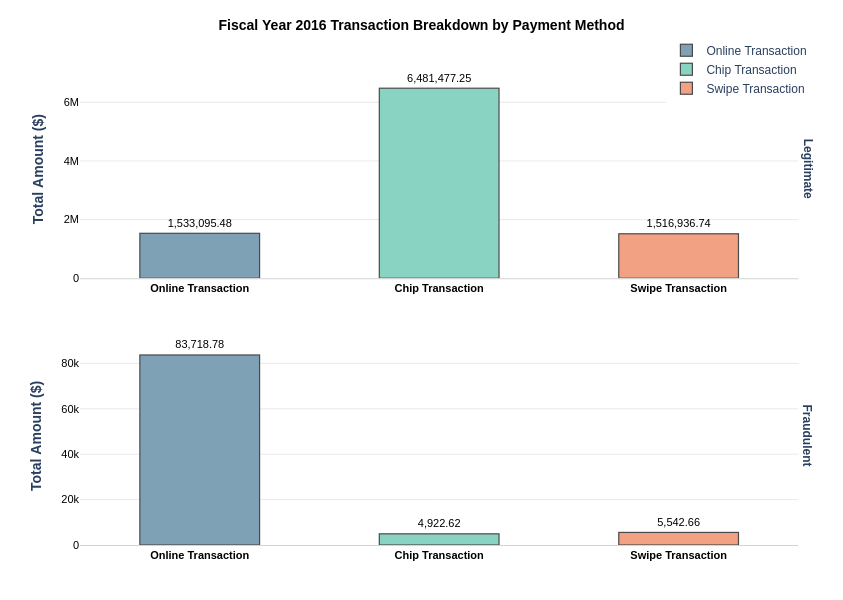

In [26]:
total_chip_plot (total_amountchip_pd, "total_amount", "<b>Total Amount ($)</b>")

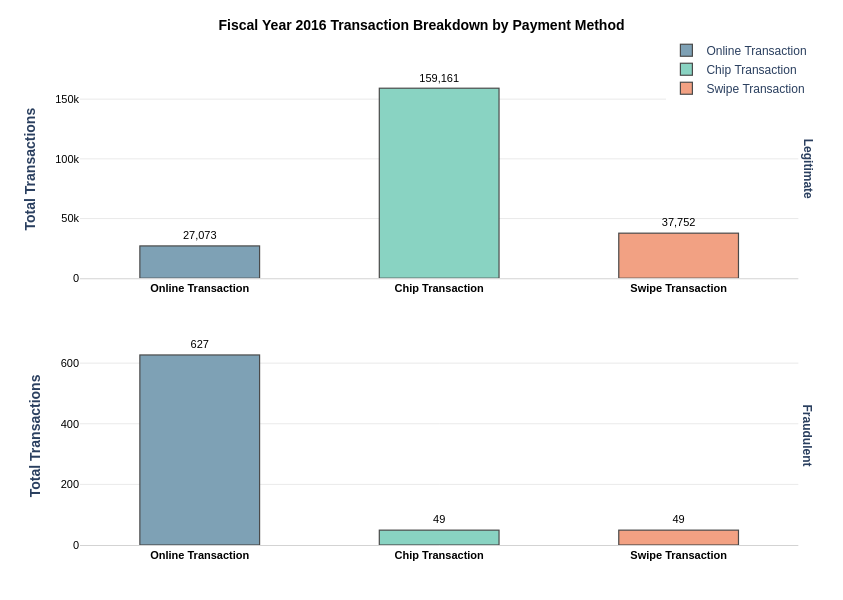

In [27]:
total_chip_plot (total_amountchip_pd, "total_transactions", "<b>Total Transactions</b>")

In [16]:
ratio_fraud = (
    total_amountchip_df
    .groupBy("use_chip")
    .pivot("target", ["Fraudulent", "Legitimate"])
    .agg(F.sum("total_transactions"))
    .withColumn(
        "Frauds per 10k Transactions",
        (F.col("Fraudulent") / (F.col("Fraudulent") + F.col("Legitimate"))) * 10000
    )
    .sort(F.col("Frauds per 10k Transactions").desc())
)

ratio_fraud.show()

+------------------+----------+----------+---------------------------+
|          use_chip|Fraudulent|Legitimate|Frauds per 10k Transactions|
+------------------+----------+----------+---------------------------+
|Online Transaction|       627|     27073|         226.35379061371842|
| Swipe Transaction|        49|     37752|          12.96262003650697|
|  Chip Transaction|        49|    159161|         3.0776961246152883|
+------------------+----------+----------+---------------------------+



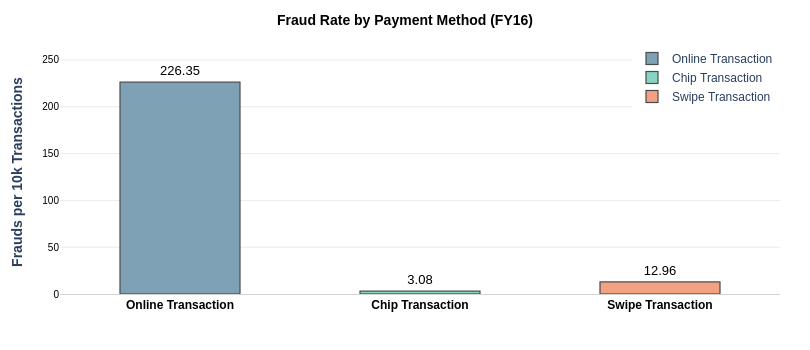

In [17]:
ratio_fraud_plot = px.bar(
    ratio_fraud, 
    x="use_chip", 
    y="Frauds per 10k Transactions", 
    color="use_chip",
    color_discrete_map= chip_color,
    category_orders={"use_chip": chip_order},
    text_auto=",.2f" 
)

ratio_fraud_plot.update_layout(
    plot_bgcolor="white", paper_bgcolor="white", showlegend=True, 
    width=600, height=350, autosize=False, margin=dict(l=60, r=30, t=50, b=50), 
    title=dict(text="<b>Fraud Rate by Payment Method (FY16)</b>", x=0.5, font=dict(size=14, color="black"),),     
    xaxis=dict(title="", showgrid=False, linecolor="#D3D3D3", tickfont=dict(size=12, color="black", weight="bold")),    
    yaxis=dict(title="<b>Frauds per 10k Transactions</b>", gridcolor="#EAEAEA", showline=False, zeroline=False,
               tickfont=dict(size=10, color="black")),   
    legend=dict(title="", orientation="v", yanchor="bottom", y=0.75, xanchor="right", x=1),    
)

ratio_fraud_plot.update_traces(
    marker_line_color="#4A4A4A", marker_line_width=1.2,
    textposition="outside", textfont=dict(size=13, color="black"),
    width=0.5,
    hovertemplate="<b>%{x}</b><br>Total: %{y:,}$<extra></extra>"
)

ratio_fraud_plot.show()


In [19]:
true_amountchip_fraud_unbiased2_df = (
    amountchip_fraud_unbiased2_df
    .filter(F.col("target") == 'Fraudulent')
    .drop("date")
)

proportion = 0.004
proportional_sample = {
    "Chip Transaction": proportion,
    "Swipe Transaction": proportion,
    "Online Transaction": proportion
}

false_amountchip_fraud_unbiased2_df = (
    amountchip_fraud_unbiased2_df
    .filter(F.col("target") == 'Legitimate')
    .drop("date")
    .sampleBy(col="use_chip", fractions=proportional_sample, seed=777)
)

sample_amountchip_fraud_unbiased2_df = (
    false_amountchip_fraud_unbiased2_df
    .unionByName(true_amountchip_fraud_unbiased2_df)
)

print(f"Rows: {sample_amountchip_fraud_unbiased2_df.count()}")

Rows: 6616


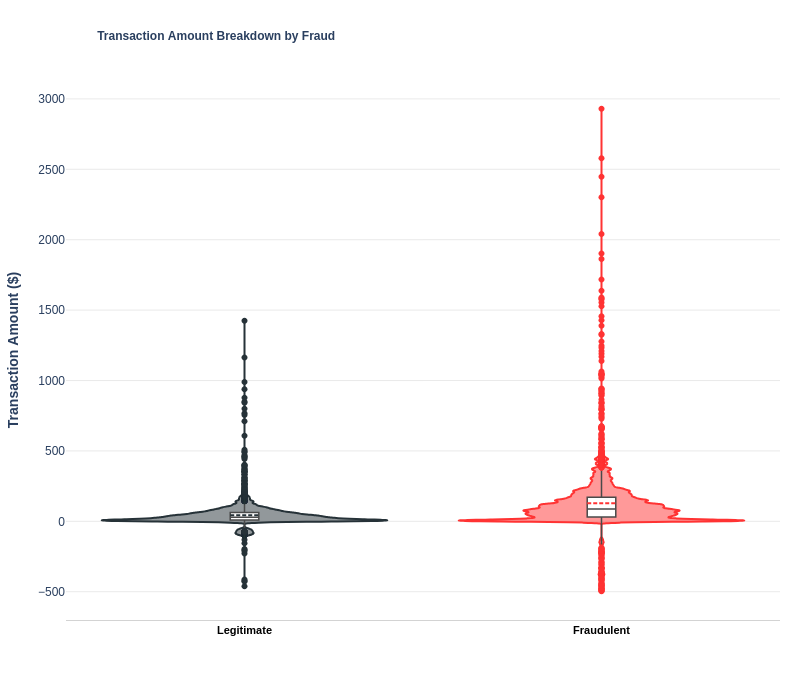

In [20]:
sample_amountchip_fraud_unbiased2_pd = sample_amountchip_fraud_unbiased2_df.toPandas()

fig_violin = px.violin(
    sample_amountchip_fraud_unbiased2_pd,
    x="target",
    y="amount", 
    color="target",        
    points="outliers",
    labels={"amount": "Transaction Amount ($)", "target": "Is Fraud?"},
    color_discrete_map={'Legitimate': '#263238', 'Fraudulent': '#FF3333'},
    box=True,
)

fig_violin.update_traces(
    box_fillcolor="white", box_line_color="#4A4A4A", box_line_width=1.5, box_width=0.1, 
    meanline_visible=True,
    width=0.8, bandwidth=6, 
    # hoveron="violins",    
)

fig_violin.update_layout(
    plot_bgcolor="white", paper_bgcolor="white", showlegend=False,
    width=800, height=700, margin=dict(l=60, r=30, t=80, b=80),
    title=dict(text="<b>Transaction Amount Breakdown by Fraud</b>", x=0.12,font=dict(size=12),),
    xaxis=dict(title="", showgrid=False, linecolor="#D3D3D3", tickfont=dict(size=11, color="black", weight="bold")),
    yaxis=dict(title="<b>Transaction Amount ($)</b>", gridcolor="#EAEAEA", showline=False, zeroline=False),   
)

fig_violin.show()

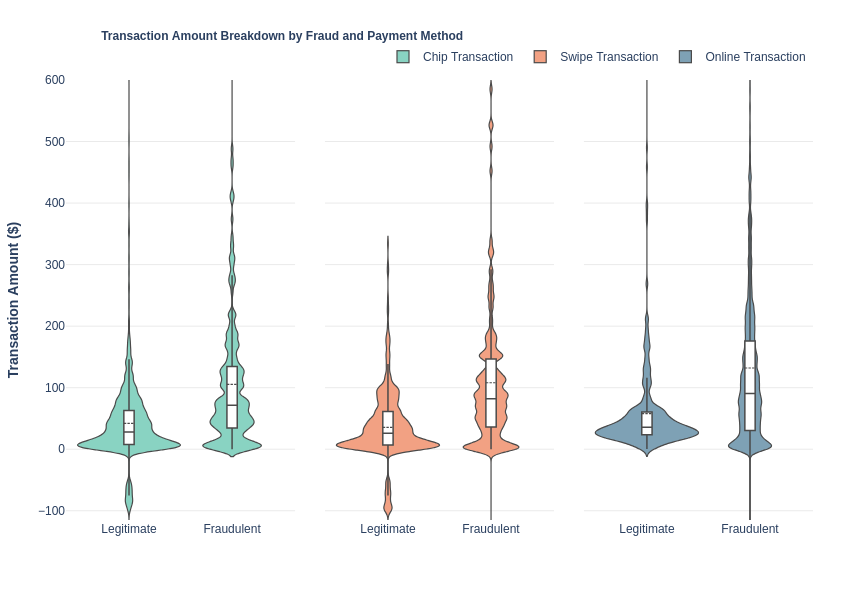

In [21]:
fig = px.violin(
    sample_amountchip_fraud_unbiased2_pd,  
    x="target",  
    y="amount",  
    color="use_chip", 
    facet_col="use_chip",             
    facet_col_spacing=0.04,
    color_discrete_map=chip_color, 
    category_orders={"target": chip_order},
    box=True,  
    points=False,
)

fig.update_layout(
    violinmode="group", boxmode="group",
    plot_bgcolor="white", paper_bgcolor="white", showlegend=True,
    width=800, height=600, autosize=False, margin=dict(l=60, r=30, t=80, b=80),
    title=dict(text="<b>Transaction Amount Breakdown by Fraud and Payment Method</b>", 
               x=0.12,font=dict(size=12),),
    legend=dict(title="", orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    yaxis=dict(title="<b>Transaction Amount ($)</b>", gridcolor="#EAEAEA", showline=False, 
               zeroline=False, 
               range=[-115, 600] 
              ),   
)

fig.update_traces(
    box_fillcolor="white", box_line_color="#4A4A4A", box_line_width=1.5, box_width=0.1, 
    meanline_visible=True,
    line=dict(color="#4A4A4A", width=1.2),    
    width=1,
    bandwidth=6, 
    hoveron="violins",    
)

fig.update_yaxes(showgrid=True, gridcolor="#EAEAEA", showline=False, zeroline=False)
fig.update_xaxes(title_text="")
fig.update_annotations(text="")

fig.for_each_trace(lambda trace: trace.update(fillcolor=chip_color.get(trace.name, "#CCCCCC")))
  
fig.show()


Analizamos el historial de transacciones de algunos clientes

In [23]:
fraudulent_client_df = (
    amountchip_fraud_unbiased_df 
    .select("client_id", "target")
    .filter(F.col("target") == 'Fraudulent')
    .distinct()
    .collect()
)

fraudulent_client_list = [row["client_id"] for row in fraudulent_client_df]
print("Total de clientes con operaciones fraudulentas:", len(fraudulent_client_list))

Total de clientes con operaciones fraudulentas: 1045


In [25]:
client_df = (
    amountchip_fraud_unbiased_df
    .filter(F.col("client_id").isin(fraudulent_client_list))
    .select("client_id", "day", "amount", "use_chip", "target")
)


Filas = client_df.count()
Columnas = len(client_df.columns)

print(f"Filas: {Filas}, Columnas: {Columnas}")
client_df.printSchema()
client_df.limit(5).toPandas()

Filas: 2728092, Columnas: 5
root
 |-- client_id: string (nullable = true)
 |-- day: date (nullable = true)
 |-- amount: double (nullable = true)
 |-- use_chip: string (nullable = true)
 |-- target: string (nullable = true)



,client_id,day,amount,use_chip,target
0,1684,2013-07-19,20.24,Online Transaction,Legitimate
1,246,2013-07-19,3.99,Swipe Transaction,Legitimate
2,150,2013-07-19,3.60,Swipe Transaction,Legitimate
3,1102,2013-07-19,4.73,Swipe Transaction,Legitimate
4,843,2013-07-19,45.71,Swipe Transaction,Legitimate


In [32]:
def plot_client_behaviour_amount(client_ID):
    client_transaction_df = client_df.filter(F.col("client_id").isin(client_ID))
    client_transaction_pd = client_transaction_df.toPandas()
    client_transaction_pd['day_dt'] = pd.to_datetime(client_transaction_pd['day'])
    client_transaction_pd['hover_date_str'] = client_transaction_pd['day_dt'].dt.strftime("%A, %d %b %Y")
    ordered_days = sorted(client_transaction_pd['day'].astype(str).unique())
    
    client_transaction_fig = px.scatter(
        client_transaction_pd,
        x="day",        
        y="amount",    
        color="target",
        facet_row="use_chip",         
        facet_row_spacing=0.08,       
        height=750, width=850,                
        opacity=0.6,
        category_orders={"target": ["Legitimate", "Fraudulent"]},
        custom_data=["hover_date_str", "use_chip"],
        title= f"<b>Transactions Behaviour, ClientID: {client_ID}</b>",
        labels={"date": "Timeline"}
    )
    
    client_transaction_fig.update_traces(
        marker=dict(line=dict(color='black', width=0.45)),
        hovertemplate="<b>%{customdata[0]}</b><br>Chip: %{customdata[1]}\
        <br>amount: %{y:,.2f}$<extra></extra>"
    )
    
    client_transaction_fig.update_layout(
        plot_bgcolor="#F5F5F5", paper_bgcolor="white", autosize=False,
        legend=dict(title="", orientation="h", yanchor="top", y=1.08, xanchor="left", x=0.65)
    )
    
    client_transaction_fig.update_xaxes(
        showticklabels=True, tickformat="%A, %d %b %Y", matches="x", tickangle=-45, nticks=12,
        type='category', categoryorder='array', categoryarray=ordered_days,
        showspikes=True, spikemode='across', spikethickness=1, spikedash='dash', spikecolor="#040404",
    
    ) 
    
    client_transaction_fig.update_xaxes(showticklabels=False, row=2)
    client_transaction_fig.update_xaxes(showticklabels=False, row=3)
    
    client_transaction_fig.update_yaxes(showgrid=True, gridcolor="#EAEAEA")
    
    client_transaction_fig.for_each_annotation(lambda a: a.update(
        text=f"<b>{a.text.split('=')[-1]}</b>",
        font=dict(size=14, color="black")
        )
    )
    
    client_transaction_fig.add_vline(x="2011-01-08", line_width=1.5, line_dash="dash")
    client_transaction_fig.add_vline(x="2015-03-30", line_width=1.5, line_dash="dash")
    
    return client_transaction_fig


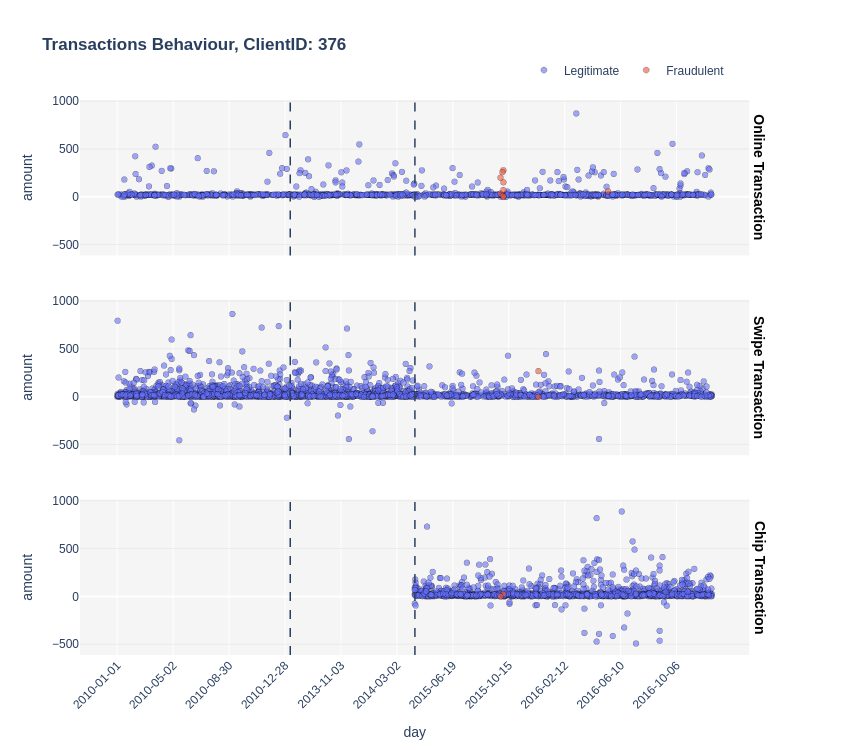

In [33]:
plot_client_behaviour_amount(fraudulent_client_list[0])

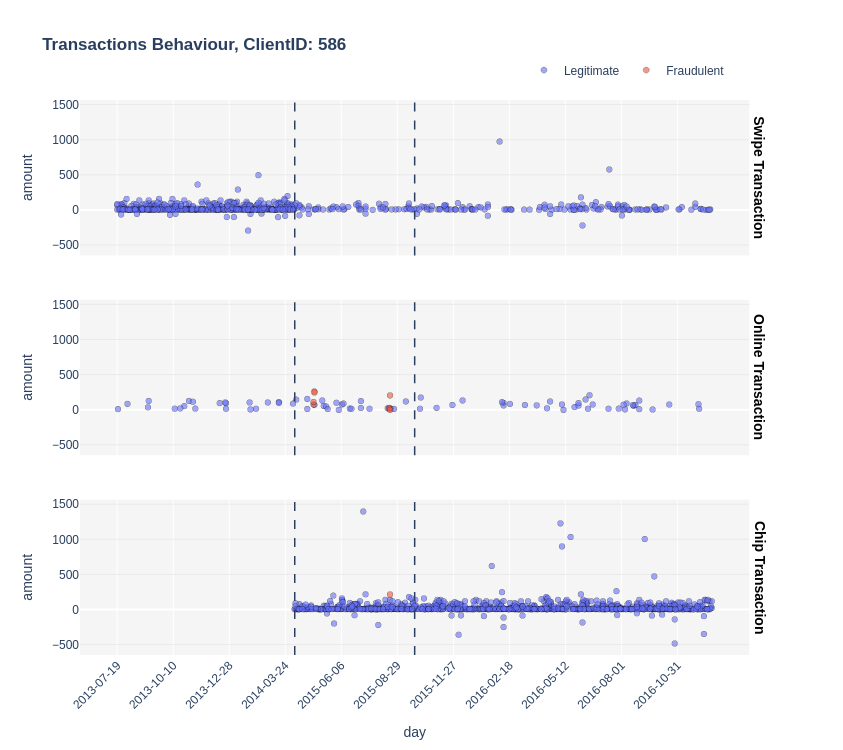

In [34]:
plot_client_behaviour_amount(fraudulent_client_list[1])

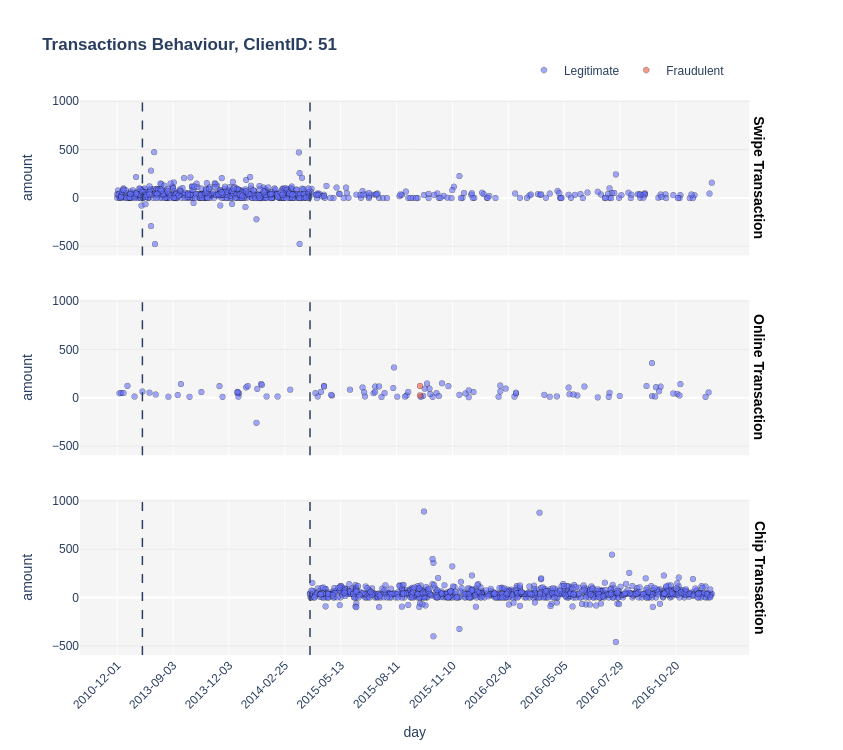

In [35]:
plot_client_behaviour_amount(fraudulent_client_list[2])